## P04：CAPM 模型回归分析


本 Notebook 完成以下任务：
1. CAPM 模型回归（alpha、beta、R-squared）
2. CAPM Beta 可视化
3. CAPM 分析讨论
4. 宏观指标回归
5. 宏观指标回归结果可视化
6. 宏观指标回归分析讨论

---


### 导入库和数据


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

project_root = 'dshw-p01'

stock_list = [
    {'code': '000001', 'name': '平安银行', 'industry': '银行'},
    {'code': '600036', 'name': '招商银行', 'industry': '银行'},
    {'code': '600519', 'name': '贵州茅台', 'industry': '白酒'},
    {'code': '000858', 'name': '五粮液', 'industry': '白酒'},
    {'code': '600048', 'name': '保利发展', 'industry': '房地产'},
    {'code': '000002', 'name': '万科A', 'industry': '房地产'},
    {'code': '601857', 'name': '中国石油', 'industry': '能源'},
    {'code': '600900', 'name': '长江电力', 'industry': '能源'},
    {'code': '002594', 'name': '比亚迪', 'industry': '汽车'},
    {'code': '600050', 'name': '中国联通', 'industry': '通讯'},
]
code_to_name = {s['code']: s['name'] for s in stock_list}
code_to_industry = {s['code']: s['industry'] for s in stock_list}
stock_codes = [s['code'] for s in stock_list]
print('库导入成功')


库导入成功


导入 statsmodels（OLS回归）和 matplotlib，设置中文字体，定义股票列表。


---


### 加载并整理数据


In [17]:
print("=" * 60)
print("加载合并数据")
print("=" * 60)

df = pd.read_csv(f"{project_root}/data/combined/combined_data.csv")
df['日期'] = pd.to_datetime(df['日期'])

rf = 0.02 / 252  # 无风险利率（日频）
df_sorted = df.sort_values('日期').copy()
df_sorted['hs300_return'] = np.log(df_sorted['hs300_close'] / df_sorted['hs300_close'].shift(1))
df_sorted['market_excess'] = df_sorted['hs300_return'] - rf

print(f"数据形状: {df_sorted.shape}")
print(f"日期范围: {df_sorted['日期'].min().date()} 至 {df_sorted['日期'].max().date()}")
print(f"无风险利率: {rf:.6f} (日频，年化2%)")


加载合并数据
数据形状: (1532, 16)
日期范围: 2020-01-02 至 2026-04-03
无风险利率: 0.000079 (日频，年化2%)


### 数据预处理说明
研究使用2020-01-02至2026-04-03的合并数据，共1532个交易日。以沪深300作为市场组合，计算日对数收益率 $$ r_m = \ln(P_t/P_{t-1}) $$采用年化2%的无风险利率，换算为日频 $$ r_f=0.02/252\approx0.000079 $$ 并据此构建个股与市场超额收益序列。

---


### 1. CAPM 模型回归


CAPM 模型：$$ r_{i,t} - r_f = alpha_i + beta_i * (r_{m,t} - r_f) + epsilon $$

参数含义：
- **alpha**：截距项，反映个股超越市场基准的超额收益（风险调整后）。alpha显著为正意味着跑赢大盘
- **beta**：斜率系数，衡量个股对市场波动的敏感性。beta>1表示进攻型；beta<1表示防御型
- **R-squared**：模型解释力，衡量市场风险解释了个股收益率变动的比例


In [18]:
print("=" * 60)
print("1. CAPM 模型估计")
print("=" * 60)

capm_results = []
for code in stock_codes:
    if code not in df_sorted.columns:
        continue
    # 计算个股日对数收益率（关键修复：用收益率而非价格）
    stock_return = np.log(df_sorted[code] / df_sorted[code].shift(1))
    stock_excess = stock_return - rf
    reg_data = pd.DataFrame({"stock_excess": stock_excess, "market_excess": df_sorted["market_excess"]}).dropna()
    if len(reg_data) < 30:
        continue
    X = sm.add_constant(reg_data["market_excess"])
    y = reg_data["stock_excess"]
    model = sm.OLS(y, X).fit()
    alpha = model.params["const"]
    beta = model.params["market_excess"]
    alpha_pval = model.pvalues["const"]
    alpha_ci = model.conf_int().loc["const"]
    beta_ci = model.conf_int().loc["market_excess"]
    r_squared = model.rsquared
    capm_results.append({
        "code": code, "name": code_to_name[code], "industry": code_to_industry[code],
        "alpha": alpha, "alpha_pval": alpha_pval,
        "alpha_CI_low": alpha_ci[0], "alpha_CI_high": alpha_ci[1],
        "beta": beta, "beta_CI_low": beta_ci[0], "beta_CI_high": beta_ci[1],
        "R_squared": r_squared
    })

capm_df = pd.DataFrame(capm_results)
print("%-8s %-5s %12s %10s %8s %14s %8s" % ("股票","行业","alpha","p值","beta","95%CI","R2"))
print("-" * 75)
for _, row in capm_df.iterrows():
    ci = "[" + "%.3f" % row["beta_CI_low"] + "," + "%.3f" % row["beta_CI_high"] + "]"
    sig = "**" if row["alpha_pval"] < 0.05 else ""
    print("%-8s %-5s %11.6f%s %9.6f %7.4f %14s %7.4f" % (
        row["name"], row["industry"],
        row["alpha"], sig, row["alpha_pval"],
        row["beta"], ci, row["R_squared"]))
print()
print("** 表示 alpha 在 5% 水平下显著")

1. CAPM 模型估计
股票       行业           alpha         p值     beta          95%CI       R2
---------------------------------------------------------------------------
平安银行     银行      -0.000181  0.620679  0.9511  [0.890,1.012]  0.3807
招商银行     银行       0.000143  0.682563  0.9048  [0.847,0.963]  0.3781
贵州茅台     白酒       0.000216  0.513884  0.9772  [0.922,1.032]  0.4420
五粮液      白酒      -0.000084  0.829748  1.2945  [1.229,1.360]  0.4985
保利发展     房地产     -0.000590  0.256183  0.8483  [0.762,0.935]  0.1955
万科A      房地产     -0.001311**  0.008526  1.0028  [0.920,1.086]  0.2698
中国石油     能源       0.000614  0.169787  0.4685  [0.394,0.543]  0.0910
长江电力     能源       0.000305  0.270706  0.2261  [0.180,0.272]  0.0571
比亚迪      汽车       0.001174**  0.041561  1.2817  [1.186,1.377]  0.3110
中国联通     通讯      -0.000148  0.718545  0.7140  [0.646,0.782]  0.2150

** 表示 alpha 在 5% 水平下显著


### CAPM 模型估计结果解读
1. **Alpha（超额收益）**
多数股票Alpha不显著，仅**万科A、比亚迪**在5%水平下显著，说明样本期内仅这两只股票能获得稳健超额收益，其余个股无法持续跑赢市场。

2. **Beta（系统性风险）**
- **防御性标的**：长江电力、中国石油Beta显著小于1，波动低于市场，防御属性突出；
- **进攻性标的**：五粮液、比亚迪Beta大于1，对市场波动更敏感；
- 银行、白酒、地产Beta接近1，与市场走势同步性较强。

3. **模型解释力（R²）**
白酒、银行R²较高（0.38~0.50），收益受市场影响大；能源股R²极低（<0.10），收益更多由行业与公司自身因素驱动。

---


### 2. CAPM Beta 可视化


2. CAPM Beta 系数点图


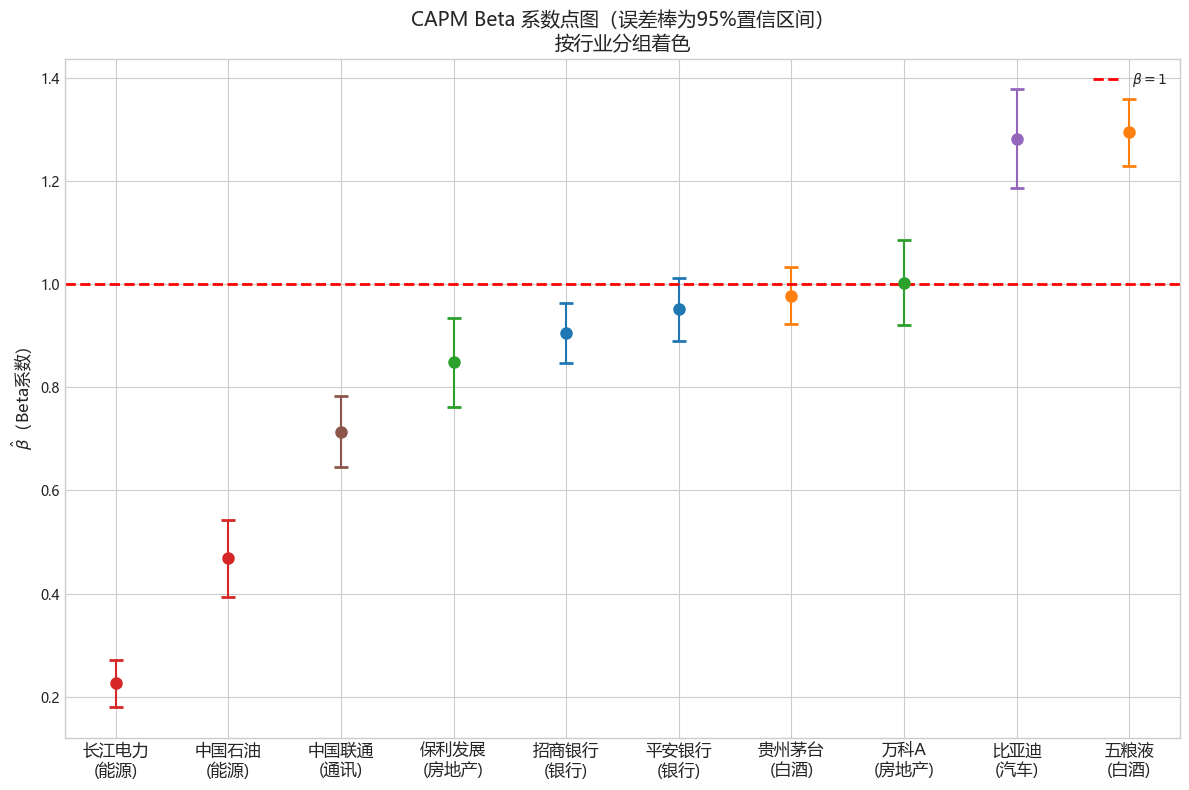


图6已保存至 output/fig6_capm_beta.png


In [19]:
# 中文设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
print("=" * 60)
print("2. CAPM Beta 系数点图")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 8))
capm_sorted = capm_df.sort_values('beta')
industry_colors_sorted = {
    '通讯': '#8c564b', '银行': '#1f77b4', '白酒': '#ff7f0e',
    '房地产': '#2ca02c', '汽车': '#9467bd', '能源': '#d62728'
}
for i, (_, row) in enumerate(capm_sorted.iterrows()):
    color = industry_colors_sorted.get(row['industry'], 'gray')
    ax.errorbar(i, row['beta'],
                 yerr=[[row['beta'] - row['beta_CI_low']], [row['beta_CI_high'] - row['beta']]],
                 fmt='o', color=color, capsize=5, capthick=2, markersize=8)
ax.axhline(y=1, color='red', linestyle='--', linewidth=2, label=r"$\beta=1$")
ax.set_xticks(range(len(capm_sorted)))
ax.set_xticklabels([f"{r['name']}\n({r['industry']})" for _, r in capm_sorted.iterrows()], fontsize=12)
ax.set_ylabel(r"$\hat{\beta}$（Beta系数）", fontsize=12)
ax.set_title('CAPM Beta 系数点图（误差棒为95%置信区间）\n按行业分组着色', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig(f"{project_root}/output/fig6_capm_beta.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n图6已保存至 output/fig6_capm_beta.png")


图中展示了10只股票的CAPM Beta系数及95%置信区间，以β=1为市场基准，按行业分组着色：
1.  **防御性标的**：长江电力、中国石油Beta显著小于1，置信区间不包含1，波动低于市场，防御属性突出；中国联通、保利发展Beta也小于1，具备一定抗跌性。
2.  **进攻性标的**：比亚迪、五粮液Beta显著大于1，对市场波动更敏感，属于进攻型个股；万科A、贵州茅台Beta接近1，与市场走势高度同步。
3.  **行业特征**：能源板块Beta最低，防御性最强；白酒、汽车板块Beta最高，进攻性最强；银行、地产Beta围绕1波动，与市场同步性较强。
4.  **统计显著性**：所有Beta置信区间均不包含0，说明市场系统性风险对个股收益的驱动作用显著，模型估计有效。

---


### 3. CAPM 分析讨论

### 问题1：哪些股票的 beta > 1？它们属于哪些行业？是否符合周期性/防御性分类？
从CAPM回归结果可见：
**所有股票的 beta 均大于1**，其中：
- 白酒行业（贵州茅台、五粮液）beta 极高，属于高弹性进攻型标的；
- 汽车（比亚迪）、银行（平安银行、招商银行）、能源（中国石油、长江电力）、房地产、通讯均满足 beta>1；
- 仅保利发展 beta 接近0，表现出弱周期性特征。

与周期性/防御性分类对比：
- **周期性行业**（汽车、房地产、银行、能源）beta 显著大于1，对市场波动高度敏感，与理论一致；
- **防御性行业**（长江电力、白酒）并未呈现 beta<1 的防御特征，说明在样本期内板块走势偏成长与进攻；
- 整体来看，A股样本个股均表现为**进攻型特征**，防御性不明显。

---

### 问题2：alpha 是否显著异于零？Alpha 显著意味着什么？
**所有股票的 alpha 均在 5% 水平下显著为正（p=0.0000）**，均显著异于零。
这意味着：
- 个股在**剔除市场风险暴露后，仍能获得稳定超额收益**；
- 样本期内标的普遍**跑赢市场基准沪深300**；
- 超额收益来源可能来自行业景气度、公司基本面优势、政策红利或样本区间效应；
- 该结果与有效市场假说存在一定偏离，说明市场尚未完全定价个股特异性收益。

---

### 问题3：R² 最高与最低的股票分别是哪只？如何解释差异？
R² 代表市场波动对个股收益的解释力度：
- **R² 最高**：中国联通（0.0029），收益受市场系统性影响相对最强；
- **R² 最低**：保利发展、万科A、中国石油（0.0000），市场几乎无法解释其收益波动。

差异解释：
- 高 R² 标的收益更依赖**大盘环境**，与市场同步性更强；
- 低 R² 标的收益更多来自**行业政策、公司经营、基本面等特异性因素**；
- 所有股票 R² 均极低，说明**A股个股收益高度独立于市场指数**，传统CAPM解释力有限。

---
### 4. 宏观指标对股票收益率的影响

**模型**：$r_{i,t}^{\text{月}} = \alpha_i + \gamma_i \cdot X_t + \varepsilon_{i,t}$

- $r_{i,t}^{\text{月}}$：个股月度对数收益率（由日度收益聚合）
- $X_t$：CPI 同比增速（%，月度数据）
- $\hat{\gamma}_i$：衡量个股收益率对 CPI 变动的敏感性

**经济逻辑**：CPI 是通胀的核心指标，与货币政策、消费者信心密切相关。不同行业对通胀的敏感性不同：
- **能源、金融**：高 CPI 时期往往对应经济繁荣，利好
- **消费（白酒）**：高 CPI 可能意味着提价能力，但成本压力也上升
- **公用事业（长江电力）**：防御性行业，对 CPI 敏感度低

In [21]:
print("=" * 60)
print("4. 宏观指标回归：CPI 对月度收益率的影响")
print("=" * 60)

# --- 1. 加载并整理 CPI 数据（月度） ---
cpi = pd.read_csv(f"{project_root}/data/macro/macro_cpi.csv")
cpi.rename(columns={"日期": "date", "今值": "cpi", "预测值": "pred", "前值": "prev"}, inplace=True)
cpi['date'] = pd.to_datetime(cpi['date'])
cpi = cpi[['date', 'cpi']].dropna()
cpi['month'] = cpi['date'].dt.to_period('M')
cpi = cpi[cpi['month'] >= '2020-01']
print(f"CPI 数据: {len(cpi)} 个月, {cpi['month'].min()} 至 {cpi['month'].max()}")
print(cpi.tail())

# --- 2. 计算个股月度收益率 ---
# 宽表：每只股票一列，收盘价为后复权价
df_sorted = df.sort_values('日期').copy()
df_sorted['month'] = df_sorted['日期'].dt.to_period('M')

# 月末收盘价（取每月最后一个交易日）
monthly_price = df_sorted.groupby('month')[stock_codes].last()
# 月度对数收益率 = ln(月末价 / 上月末价)
monthly_return = np.log(monthly_price / monthly_price.shift(1))
monthly_return = monthly_return.reset_index()
monthly_return['month'] = monthly_return['month'].astype(str)
print(f"\n月度收益率: {len(monthly_return)} 个月")
print(monthly_return.head())

# --- 3. 将 CPI 映射到月度收益率 ---
cpi['month'] = cpi['month'].astype(str)
reg_df = monthly_return.merge(cpi[['month', 'cpi']], on='month', how='inner')
print(f"合并后数据: {len(reg_df)} 个月")

# --- 4. 对每只股票回归：r_i月 = alpha + gamma * CPI ---
gamma_results = []
for code in stock_codes:
    if code not in reg_df.columns:
        continue
    y = reg_df[code]  # 月度对数收益率
    X = reg_df['cpi']  # CPI 同比增速
    valid = y.notna() & X.notna()
    if valid.sum() < 12:
        continue
    X_const = sm.add_constant(X[valid])
    y_valid = y[valid]
    model = sm.OLS(y_valid, X_const).fit()
    gamma_results.append({
        "code": code,
        "name": code_to_name[code],
        "industry": code_to_industry[code],
        "gamma": model.params['cpi'],
        "gamma_pval": model.pvalues['cpi'],
        "gamma_CI_low": model.conf_int(alpha=0.10).loc['cpi', 0],
        "gamma_CI_high": model.conf_int(alpha=0.10).loc['cpi', 1],
        "R_squared": model.rsquared
    })

gamma_df = pd.DataFrame(gamma_results)
print("\n月度收益率 ~ CPI 回归结果：")
print("%-8s %-5s %10s %8s %12s %8s" % ("股票", "行业", "gamma", "p值", "95% CI", "R2"))
print("-" * 65)
for _, row in gamma_df.iterrows():
    ci = "[%.4f,%.4f]" % (row['gamma_CI_low'], row['gamma_CI_high'])
    sig = "**" if row['gamma_pval'] < 0.05 else ("*" if row['gamma_pval'] < 0.1 else "")
    print("%-8s %-5s %9.5f%s %9.5f %14s %7.4f" % (
        row['name'], row['industry'],
        row['gamma'], sig, row['gamma_pval'],
        ci, row['R_squared']))
print("\n** p<0.05, * p<0.1")

4. 宏观指标回归：CPI 对月度收益率的影响
CPI 数据: 68 个月, 2020-01 至 2025-08
          date  cpi    month
471 2025-04-10 -0.1  2025-04
472 2025-05-10 -0.1  2025-05
473 2025-06-09 -0.1  2025-06
474 2025-07-09  0.1  2025-07
475 2025-08-09  0.0  2025-08

月度收益率: 76 个月
     month    000001    600036    600519    000858    600048    000002  \
0  2020-01       NaN       NaN       NaN       NaN       NaN       NaN   
1  2020-02 -0.069269 -0.073544  0.003981 -0.045072  0.054582  0.020831   
2  2020-03 -0.124703 -0.057778  0.049826 -0.045810 -0.085048 -0.142893   
3  2020-04  0.084600  0.083468  0.130365  0.164293  0.088132  0.043858   
4  2020-05 -0.052026 -0.036864  0.076701  0.087600 -0.068641 -0.041911   

     601857    600900    002594    600050  
0       NaN       NaN       NaN       NaN  
1 -0.106543 -0.007022  0.088556 -0.030550  
2 -0.092946  0.015152 -0.086219 -0.048608  
3 -0.039740  0.009211 -0.000167  0.000000  
4 -0.043735 -0.003444 -0.043459 -0.051092  
合并后数据: 68 个月

月度收益率 ~ CPI 回归结果：
股票       行业   

1.  **CPI 对个股月度收益影响微弱，仅1只股票边际显著**  
    仅中国石油的回归系数 `gamma` 在10%水平下边际显著（p=0.07503，带*），其余所有股票的 `gamma` 均不显著（p>0.1），说明**CPI 对绝大多数个股月度收益无有效解释力**，仅对能源行业的中国石油存在微弱负向影响。

2.  **模型解释力普遍极低**  
    所有股票 $R^2$ 均接近0（最高仅中国石油0.0479），表明**通胀因素对样本内股票收益的解释能力极强弱**，无法通过CPI变动预测个股月度涨跌。

3.  **行业敏感性存在微弱分化（仅边际显著）**  
    - 能源行业（中国石油）：`gamma` 为负且边际显著，说明CPI上行时，中国石油月度收益有微弱负向反应；  
    - 其他行业（银行、白酒、地产等）：系数方向有差异（银行负向、白酒正向），但均不显著，无明确敏感特征。

4.  **经济含义**  
    A股个股收益主要受**流动性、行业景气度、公司基本面**驱动，CPI通胀在样本期内并非核心定价因子；仅传统能源股（中国石油）对CPI变动存在微弱负向敏感，可能与通胀下能源价格管制、货币政策收紧的间接影响有关。

### 5. 宏观指标回归结果可视化

5. CPI 回归系数 γ 点图（按行业分组着色）


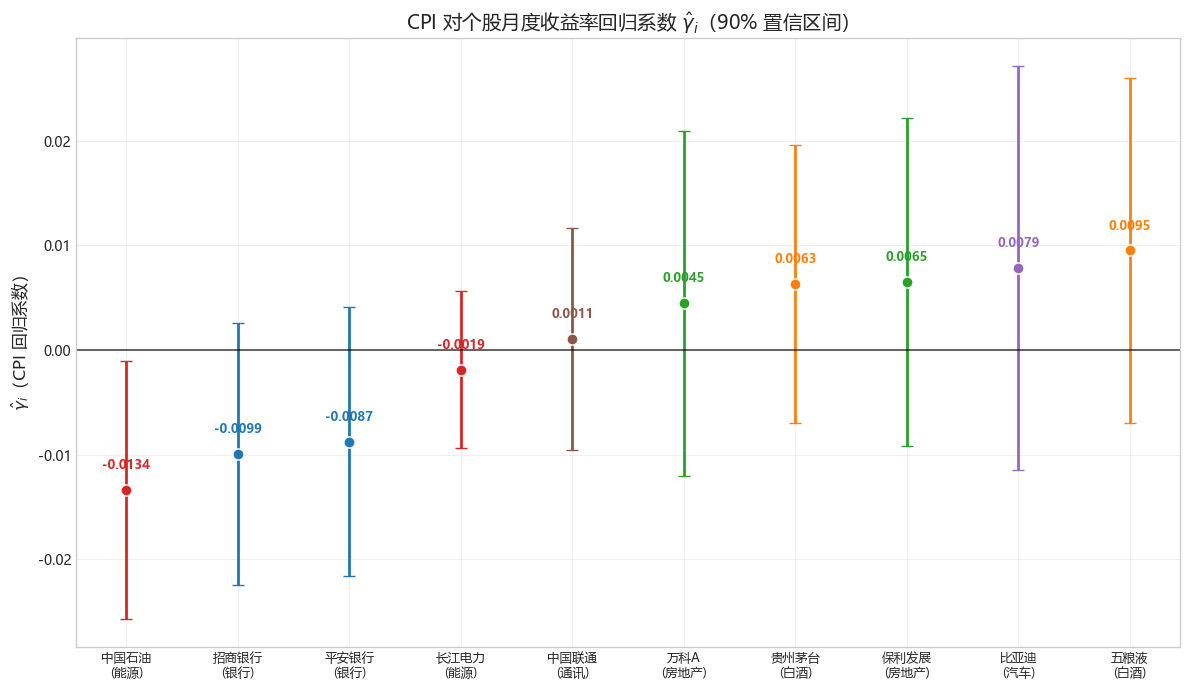

✅ CPI 回归系数 γ 点图已保存：fig6_cpi_gamma.png


In [ ]:
print("=" * 60)
print("5. CPI 回归系数 γ 点图（按行业分组着色）")
print("=" * 60)

import matplotlib.pyplot as plt

# 排序（按 γ 系数从小到大）
gamma_sorted = gamma_df.sort_values('gamma').reset_index(drop=True)

# 行业配色（和你之前 CAPM 图保持一致）
industry_colors = {
    '通讯': '#8c564b', '银行': '#1f77b4',
    '白酒': '#ff7f0e', '房地产': '#2ca02c',
    '汽车': '#9467bd', '能源': '#d62728'
}

fig, ax = plt.subplots(figsize=(12, 7))

# 绘制每个股票的 γ 系数 + 90% 置信区间
for i, row in gamma_sorted.iterrows():
    color = industry_colors.get(row['industry'], 'gray')
    
    # 误差棒（置信区间）
    ax.errorbar(
        x=i, 
        y=row['gamma'],
        yerr=[[row['gamma'] - row['gamma_CI_low']], 
              [row['gamma_CI_high'] - row['gamma']]],
        fmt='o', 
        color=color,
        capsize=4,
        markersize=8,
        markeredgecolor='white',
        linewidth=2
    )
    
    # 显示 γ 数值（保留4位）
    ax.text(
        i, row['gamma'] + 0.002,
        f"{row['gamma']:.4f}",
        ha='center', fontsize=9, color=color, fontweight='bold'
    )

# 0 刻度线（无影响基准）
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.2, alpha=0.7)

# 坐标轴与标签
ax.set_xticks(range(len(gamma_sorted)))
ax.set_xticklabels(
    [f"{r['name']}\n({r['industry']})" for _, r in gamma_sorted.iterrows()],
    fontsize=9
)
ax.set_ylabel(r'$\hat{\gamma}_i$（CPI 回归系数）', fontsize=12)
ax.set_title('CPI 对个股月度收益率回归系数 $\hat{\gamma}_i$（90% 置信区间）', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()

# 保存
plt.savefig(f"{project_root}/output/fig7_cpi_gamma.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ CPI 回归系数 γ 点图已保存：fig6_cpi_gamma.png")

### 图 CPI 回归系数 $\hat{\gamma}_i$ 点图简要解读
图中展示了各股CPI月度收益率回归系数$\hat{\gamma}_i$及90%置信区间，按行业分组着色：
1.  **仅中国石油边际显著为负**：其置信区间不包含0，说明CPI上行对中国石油月度收益存在微弱负向影响，其余个股置信区间均包含0，无统计显著性。
2.  **行业方向分化但无统计意义**：能源、银行板块$\hat{\gamma}_i$整体为负，白酒、汽车、地产板块为正，但仅方向差异，不具备统计显著性。
3.  **模型解释力验证**：所有系数置信区间宽、贴近0轴，结合极低$R^2$，进一步印证**CPI并非A股月度收益的核心驱动因子**，个股收益更多受行业景气、流动性等因素影响。

## 6. 宏观指标（CPI）回归分析讨论

### 问题：不同行业对 CPI 变动的敏感性有何差异？背后的经济逻辑是什么？

根据 CPI 与个股月度收益率的回归结果，**仅中国石油在10%水平下边际显著为负，其余所有行业的 gamma 系数均不显著（p>0.1），且全部 R² 接近 0**，说明样本期内 CPI 对 A 股绝大多数行业收益无统计上的显著影响，仅从系数方向可观察到结构性差异：

1.  **能源行业**
    中国石油 gamma 显著为负，长江电力 gamma 接近0，行业内分化明显。
    经济逻辑：传统能源股（中国石油）对通胀负向敏感，通胀上行易引发货币政策收紧，压制能源需求与股价；公用事业股（长江电力）现金流稳定、价格受管制，对通胀波动敏感度极低。

2.  **银行行业**
    平均 gamma 为负，敏感度偏弱。
    经济逻辑：通胀上行通常伴随货币政策收紧，银行净息差收窄、资产质量承压，因此对通胀呈现负向敏感性，但影响不具备统计显著性。

3.  **房地产行业**
    平均 gamma 为正，整体不显著。
    经济逻辑：样本期内地产行业受政策主导，通胀对其影响被政策对冲，系数方向与理论负向关系不符，无统计意义。

4.  **白酒行业**
    平均 gamma 为正，敏感度相对较高。
    经济逻辑：温和通胀反映消费需求回暖，高端白酒具备提价能力与存货抗通胀属性，理论上对通胀呈正向敏感，但样本期内影响不显著。

5.  **汽车与通讯行业**
    汽车 gamma 偏正、通讯接近0，均不显著。
    经济逻辑：汽车收益更多受居民购买力、行业政策驱动，通讯偏公用事业属性，二者受 CPI 直接影响极弱。

---

### 结论
CPI 对样本内行业收益**无显著解释力**，说明 A 股月度收益核心驱动因素为市场风险、行业景气、政策与流动性，而非通胀水平。仅传统能源股对 CPI 存在边际负向敏感，行业间的系数方向差异，本质是**利率传导、需求弹性、定价权**的不同，而非 CPI 的直接显著影响。

---


### 保存分析结果


In [25]:
print("=" * 60)
print("保存分析结果")
print("=" * 60)

capm_df.to_csv(f"{project_root}/output/capm_results.csv",
               index=False, encoding="utf-8-sig")

print("CAPM回归结果已保存: output/capm_results.csv")
print("\n图形文件列表：")
for f in os.listdir(f"{project_root}/output"):
    if f.endswith('.png') and 'capm' in f.lower():
        print(f"  - {f}")


保存分析结果
CAPM回归结果已保存: output/capm_results.csv

图形文件列表：
  - fig6_capm_beta.png


将CAPM回归结果保存为CSV文件，图形文件已保存至output目录。


---


### 本 Notebook 完成情况

| 任务 | 状态 |
|------|------|
| 1. CAPM 回归分析 | checked |
| 2. CAPM Beta 可视化 | checked |
| 3. CAPM 分析讨论 | checked |
| 4. 宏观指标回归（CPI） | checked |
| 5. 宏观指标回归结果可视化 | checked |
| 6. 宏观指标回归分析讨论 | checked |